# **Blinkit Analysis**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importing Data

In [2]:
dt = pd.read_csv('D:\\sampledata\\Blinkit\\blinkit_data.csv')
dt.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


## Exploring Data

In [3]:
dt.shape

(8523, 12)

In [4]:
dt.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [5]:
dt.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

In [6]:
print(dt['Item Fat Content'].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


## Data Cleaning

In [7]:
dt['Item Fat Content'] = dt['Item Fat Content'].replace({ 'LF':'Low Fat', 'low fat':'Low Fat','reg':'Regular' })

In [8]:
dt['Item Fat Content'].unique()

array(['Regular', 'Low Fat'], dtype=object)

## KPI - Key Performance Indicator

In [9]:
# Total sales
total_sales = dt['Sales'].sum()
print(f"Total sales: ${total_sales:,.0f}")

Total sales: $1,201,681


In [10]:
# Average 
average_sales = dt['Sales'].mean()
print(f"average sales: {average_sales:.2f}")

average sales: 140.99


In [11]:
# Item sold
items_sold = dt['Sales'].count()
items_sold

8523

In [12]:
# Ratings
ratings = dt['Rating'].mean()
print(f"Ratings: {ratings:.2f}")

Ratings: 3.97


# Chart

### Sales by Fate content

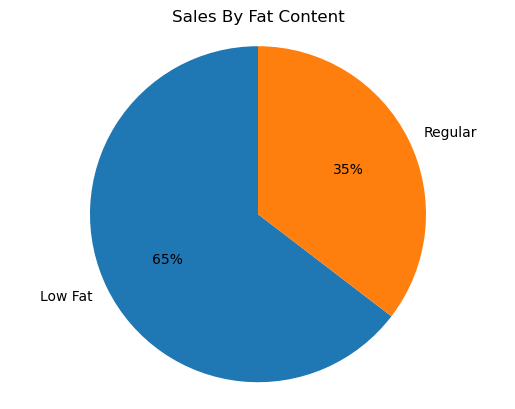

In [13]:
sales_by_fat = dt.groupby('Item Fat Content') ['Sales'].sum()

plt.pie(sales_by_fat, labels = sales_by_fat.index, autopct= '%.0f%%', startangle= 90)
plt.title('Sales By Fat Content')
plt.axis('equal')
plt.show()

### Sales by Item Type

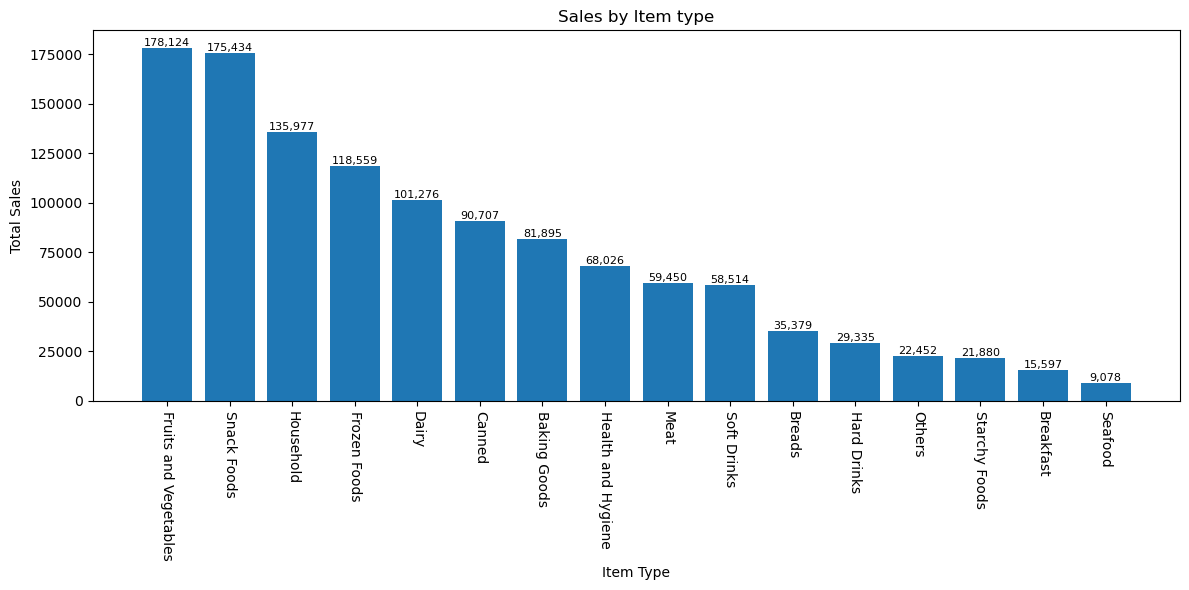

In [14]:
sales_by_item_type = dt.groupby('Item Type') ['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
bars = plt.bar(sales_by_item_type.index,sales_by_item_type.values)

plt.xticks(rotation=-90)
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title('Sales by Item type')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{bar.get_height():,.0f}', ha = 'center', va='bottom', fontsize = 8 )

plt.tight_layout()
plt.show()

### Fat Content By Outlet for Total Sales

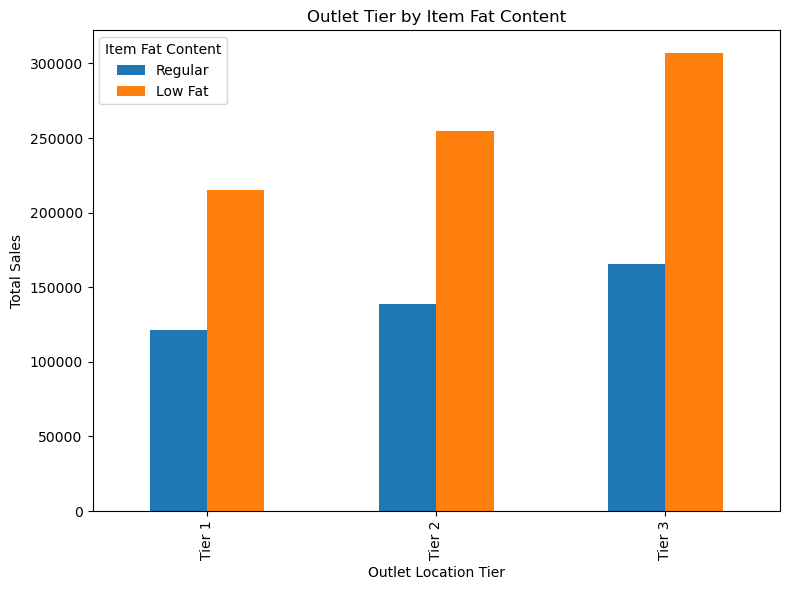

In [15]:
grouped = dt.groupby(['Outlet Location Type','Item Fat Content']) ['Sales'].sum().unstack()
grouped = grouped[['Regular','Low Fat']]

ax = grouped.plot(kind='bar',figsize=(8,6), title='Outlet Tier by Item Fat Content')
plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
plt.legend(title='Item Fat Content')
plt.tight_layout()
plt.show()

### Total Sales By Outlet Establishment

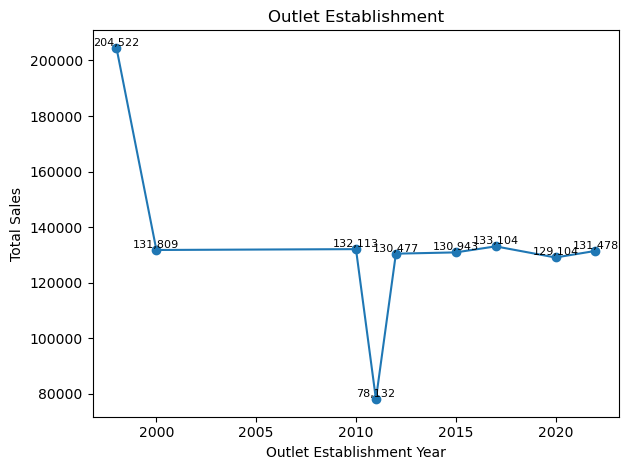

In [19]:
sales_by_establishment = dt.groupby('Outlet Establishment Year') ['Sales'].sum().sort_index()

plt.Figure(figsize=(9,5))
plt.plot(sales_by_establishment.index,sales_by_establishment.values, marker='o', linestyle = '-')

plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment')

for x,y in zip(sales_by_establishment.index,sales_by_establishment.values):
    plt.text(x,y,f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
grouped = dt[dt['Outlet Establishment Year'] == 2000].groupby(['Outlet Location Type', 'Item Fat Content']) ['Sales'].sum().unstack(fill_value=0)

ax = grouped.plot(kind='bar', figsize=(9,6), title='Sales in 2000 by outlets')
plt.xlabel('Outlet Location Type')
plt.ylabel('Total Sales')
plt.legend(title='Item Fat Content')

plt.tight_layout()
plt.show()

### Sales by outlet size

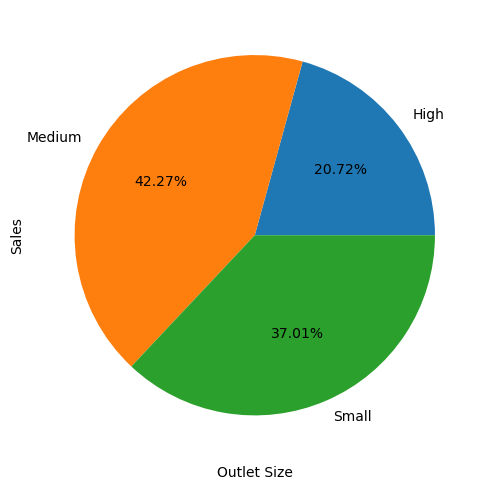

In [35]:
sales_by_size = dt.groupby('Outlet Size') ['Sales'].sum()

plt.figure(figsize=(6,5))
plt.pie(sales_by_size, labels = sales_by_size.index, autopct='%1.2f%%')

plt.xlabel('Outlet Size')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()

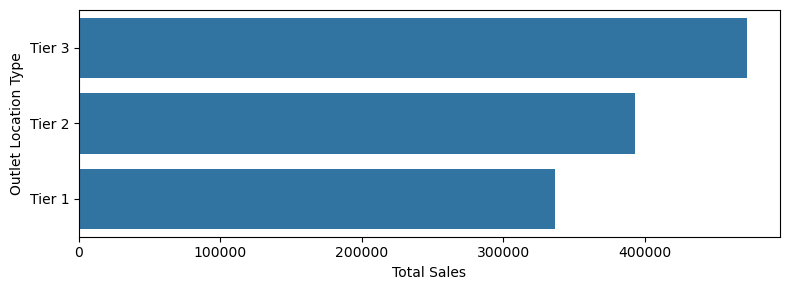

In [36]:
sales_location = dt.groupby('Outlet Location Type') ['Sales'].sum().reset_index()
sales_location = sales_location.sort_values('Sales',ascending=False)

plt.figure(figsize=(8,3))

ax = sns.barplot(x='Sales', y='Outlet Location Type', data = sales_location)

plt.xlabel("Total Sales")
plt.ylabel("Outlet Location Type")

plt.tight_layout()
plt.show()